# Step 5. 복합 경보 시스템 (Composite Alert System)

기존 프로젝트의 VIX 고정 임계값(20/28/35) 경보를 **7개 지표 가중 복합 스코어(0-100)**로 대체합니다.  
5일 디바운싱(지속성 검증)으로 오보를 방지하고, 경보 정밀도를 평가합니다.

| 지표 | 가중치 | 방향 | 범위 |
|------|--------|------|------|
| VIX_level | 25% | 상승=위험 | 12 ~ 45 |
| VIX_contango | 15% | 하락=위험 | -0.15 ~ 0.10 |
| HY_spread | 20% | 상승=위험 | 2.5 ~ 8.0 |
| yield_curve | 10% | 하락=위험 | -0.5 ~ 2.5 |
| SKEW_level | 10% | 상승=위험 | 110 ~ 170 |
| claims_zscore | 10% | 상승=위험 | -2 ~ 3 |
| Cu_Au_ratio_chg | 10% | 하락=위험 | -0.10 ~ 0.05 |

In [1]:
# ============================================================
# 라이브러리 및 데이터 로드
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120

DATA_DIR = os.path.join(os.getcwd(), 'data')
IMG_DIR  = os.path.join(os.getcwd(), 'images')

df_reg   = pd.read_csv(os.path.join(DATA_DIR, 'df_reg_v2.csv'), index_col=0, parse_dates=True)
df_regime = pd.read_csv(os.path.join(DATA_DIR, 'regime_history.csv'), index_col=0, parse_dates=True)

print(f'df_reg_v2      : {df_reg.shape}')
print(f'regime_history : {df_regime.shape}')

df_reg_v2      : (1045, 34)
regime_history : (1045, 7)


## 5-1. 복합 스트레스 스코어 계산

In [2]:
# ============================================================
# 복합 스트레스 스코어 함수 정의
# ============================================================

# 각 지표의 가중치, 방향, 정규화 범위 정의
SCORE_COMPONENTS = {
    'VIX_level':       {'weight': 0.25, 'direction': +1, 'lo': 12,    'hi': 45},
    'VIX_contango':    {'weight': 0.15, 'direction': -1, 'lo': -0.15, 'hi': 0.10},
    'HY_spread':       {'weight': 0.20, 'direction': +1, 'lo': 2.5,   'hi': 8.0},
    'yield_curve':     {'weight': 0.10, 'direction': -1, 'lo': -0.5,  'hi': 2.5},
    'SKEW_level':      {'weight': 0.10, 'direction': +1, 'lo': 110,   'hi': 170},
    'claims_zscore':   {'weight': 0.10, 'direction': +1, 'lo': -2,    'hi': 3},
    'Cu_Au_ratio_chg': {'weight': 0.10, 'direction': -1, 'lo': -0.10, 'hi': 0.05},
}

def compute_stress_score(row):
    """
    일별 복합 스트레스 스코어 (0-100) 계산.
    
    각 지표를 [0, 1]로 정규화한 뒤 가중 합산.
    direction = +1 이면 값이 클수록 위험 (예: VIX),
    direction = -1 이면 값이 작을수록 위험 (예: contango가 음수일 때).
    """
    score = 0
    for feat, cfg in SCORE_COMPONENTS.items():
        val = row.get(feat, np.nan)
        if np.isnan(val):
            continue
        # 0~1 정규화
        normed = np.clip((val - cfg['lo']) / (cfg['hi'] - cfg['lo']), 0, 1)
        # 방향 반전 (하락=위험인 경우)
        if cfg['direction'] < 0:
            normed = 1 - normed
        score += cfg['weight'] * normed * 100
    return score

# 전체 기간에 대해 스코어 계산
df_reg['stress_score'] = df_reg.apply(compute_stress_score, axis=1)

print('=== 복합 스트레스 스코어 통계 ===')
print(df_reg['stress_score'].describe().round(2))

=== 복합 스트레스 스코어 통계 ===
count    1045.00
mean       32.54
std         7.92
min        15.25
25%        26.98
50%        31.36
75%        36.86
max        72.15
Name: stress_score, dtype: float64


## 5-2. 경보 등급 분류 + 디바운싱

In [3]:
# ============================================================
# 경보 등급 분류
# ============================================================

# 스코어 → 경보 등급 매핑
ALERT_THRESHOLDS = [
    (75, 3, 'L3 위험'),    # 75 이상
    (50, 2, 'L2 경고'),    # 50~75
    (25, 1, 'L1 주의'),    # 25~50
    (0,  0, '정상'),       # 0~25
]

def score_to_alert(score):
    """스코어 → 경보 등급 (0~3) 및 이름 반환."""
    for threshold, level, name in ALERT_THRESHOLDS:
        if score >= threshold:
            return level, name
    return 0, '정상'

# Raw 경보 등급 (디바운싱 전)
alerts_raw = df_reg['stress_score'].apply(lambda s: score_to_alert(s)[0])

# ── 디바운싱: 5일 중 3일 이상 해당 등급이면 확정 ──
def debounce_alerts(raw_alerts, window=5, threshold=3):
    """
    경보 오보 방지를 위한 디바운싱.
    최근 window일 중 threshold일 이상 해당 등급이면 확정,
    아니면 1단계 하향.
    """
    debounced = raw_alerts.copy()
    for i in range(window, len(raw_alerts)):
        recent = raw_alerts.iloc[i-window:i]
        current = raw_alerts.iloc[i]
        # 최근 window일 중 현재 등급 이상인 날이 threshold일 미만이면 하향
        if (recent >= current).sum() < threshold:
            debounced.iloc[i] = max(0, current - 1)
    return debounced

df_reg['alert_raw'] = alerts_raw
df_reg['alert_debounced'] = debounce_alerts(alerts_raw)

# 경보 이름 매핑
alert_name_map = {0: '정상', 1: 'L1 주의', 2: 'L2 경고', 3: 'L3 위험'}
df_reg['alert_name'] = df_reg['alert_debounced'].map(alert_name_map)

# 분포 요약
print('=== 경보 등급 분포 ===')
print('\n[디바운싱 전]')
print(df_reg['alert_raw'].map(alert_name_map).value_counts().sort_index())
print('\n[디바운싱 후]')
print(df_reg['alert_name'].value_counts().sort_index())

=== 경보 등급 분포 ===

[디바운싱 전]
alert_raw
L1 주의    859
L2 경고     27
정상       159
Name: count, dtype: int64

[디바운싱 후]
alert_name
L1 주의    837
L2 경고     11
정상       197
Name: count, dtype: int64


## 5-3. 경보 정밀도 / 오보율 평가

경보가 "실제 위험"을 맞추는지 평가합니다:  
- **정밀도**: L1+ 경보 발동 후 5일 내 포트폴리오 변동성이 상위 25% 이상인 비율  
- **오보율**: L1+ 경보 발동 후 5일 내 변동성 상승이 없는 비율

In [4]:
# ============================================================
# 경보 정밀도 / 오보율 평가
# ============================================================

rv = df_reg['rv_neutral']
rv_75pct = rv.quantile(0.75)  # 상위 25% 변동성 기준

def evaluate_alerts(alert_series, rv_series, look_ahead=5, rv_threshold=None):
    """
    경보 정밀도 평가.
    L1 이상 경보 발동일의 look_ahead일 이내 최대 변동성이 기준 초과 여부.
    """
    if rv_threshold is None:
        rv_threshold = rv_series.quantile(0.75)
    
    alert_dates = alert_series[alert_series >= 1].index
    hits = 0
    misses = 0
    
    for date in alert_dates:
        # 경보 발동 후 look_ahead일 내 최대 변동성
        loc = rv_series.index.get_loc(date)
        if loc + look_ahead >= len(rv_series):
            continue
        future_rv = rv_series.iloc[loc:loc+look_ahead].max()
        if future_rv >= rv_threshold:
            hits += 1
        else:
            misses += 1
    
    total = hits + misses
    precision = hits / total if total > 0 else 0
    false_alarm = misses / total if total > 0 else 0
    return {
        '총 경보 수': total,
        '적중 수': hits,
        '오보 수': misses,
        '정밀도': f'{precision:.1%}',
        '오보율': f'{false_alarm:.1%}',
    }

# 기존 VIX-only 경보 (비교용)
vix_alert = (df_reg['VIX_level'] >= 20).astype(int) + \
            (df_reg['VIX_level'] >= 28).astype(int) + \
            (df_reg['VIX_level'] >= 35).astype(int)

print('=== 경보 정밀도 비교 ===')
print(f'변동성 기준: rv >= {rv_75pct:.4f} (상위 25%)')
print()

# (A) VIX-only 경보
result_vix = evaluate_alerts(vix_alert, rv)
print('[VIX-only 경보 (기존)]')
for k, v in result_vix.items():
    print(f'  {k}: {v}')

# (B) 복합 스코어 경보 (디바운싱 후)
result_composite = evaluate_alerts(df_reg['alert_debounced'], rv)
print('\n[복합 스코어 경보 (디바운싱)]')
for k, v in result_composite.items():
    print(f'  {k}: {v}')

=== 경보 정밀도 비교 ===
변동성 기준: rv >= 0.1184 (상위 25%)

[VIX-only 경보 (기존)]
  총 경보 수: 371
  적중 수: 259
  오보 수: 112
  정밀도: 69.8%
  오보율: 30.2%

[복합 스코어 경보 (디바운싱)]
  총 경보 수: 848
  적중 수: 301
  오보 수: 547
  정밀도: 35.5%
  오보율: 64.5%


## 5-4. 시각화

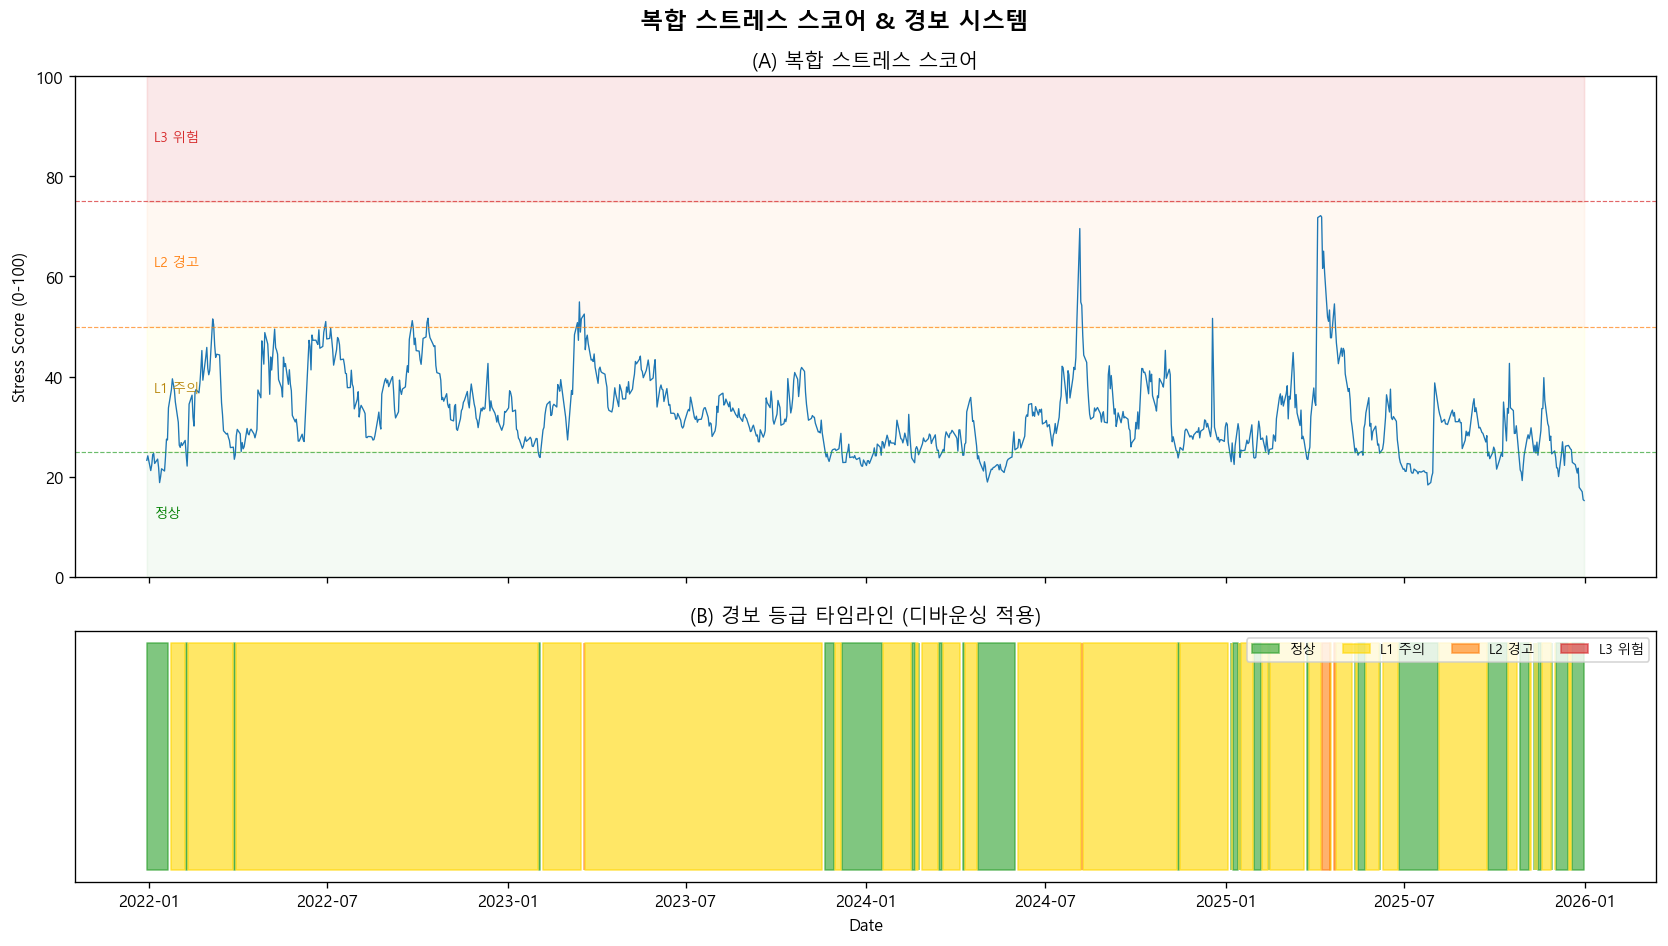

저장: images/alert_01_score_timeline.png


In [5]:
# ============================================================
# (1) 복합 스코어 시계열 + 경보 등급 음영
# ============================================================

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                         gridspec_kw={'height_ratios': [2, 1]})
fig.suptitle('복합 스트레스 스코어 & 경보 시스템', fontsize=14, fontweight='bold')

# (A) 스트레스 스코어 시계열
ax = axes[0]
ax.plot(df_reg.index, df_reg['stress_score'], color='#1f77b4', linewidth=0.8, label='Stress Score')
ax.axhline(25, color='#2ca02c', linestyle='--', linewidth=0.7, alpha=0.7)
ax.axhline(50, color='#ff7f0e', linestyle='--', linewidth=0.7, alpha=0.7)
ax.axhline(75, color='#d62728', linestyle='--', linewidth=0.7, alpha=0.7)
# 음영
ax.fill_between(df_reg.index, 0, 25, color='#2ca02c', alpha=0.05)
ax.fill_between(df_reg.index, 25, 50, color='#ffff00', alpha=0.05)
ax.fill_between(df_reg.index, 50, 75, color='#ff7f0e', alpha=0.05)
ax.fill_between(df_reg.index, 75, 100, color='#d62728', alpha=0.1)
ax.set_ylabel('Stress Score (0-100)')
ax.set_ylim(0, 100)
ax.set_title('(A) 복합 스트레스 스코어')
# 텍스트 라벨
ax.text(df_reg.index[5], 12, '정상', fontsize=8, color='green')
ax.text(df_reg.index[5], 37, 'L1 주의', fontsize=8, color='#b8860b')
ax.text(df_reg.index[5], 62, 'L2 경고', fontsize=8, color='#ff7f0e')
ax.text(df_reg.index[5], 87, 'L3 위험', fontsize=8, color='#d62728')

# (B) 경보 등급 (디바운싱 후)
ax = axes[1]
alert_colors = {0: '#2ca02c', 1: '#FFD700', 2: '#ff7f0e', 3: '#d62728'}
for level in [0, 1, 2, 3]:
    mask = df_reg['alert_debounced'] == level
    ax.fill_between(df_reg.index, 0, 1, where=mask,
                    color=alert_colors[level], alpha=0.6,
                    label=alert_name_map[level])
ax.set_yticks([])
ax.set_title('(B) 경보 등급 타임라인 (디바운싱 적용)')
ax.legend(loc='upper right', fontsize=8, ncol=4)
ax.set_xlabel('Date')

plt.tight_layout()
fig.savefig(os.path.join(IMG_DIR, 'alert_01_score_timeline.png'), bbox_inches='tight')
plt.show()
print('저장: images/alert_01_score_timeline.png')

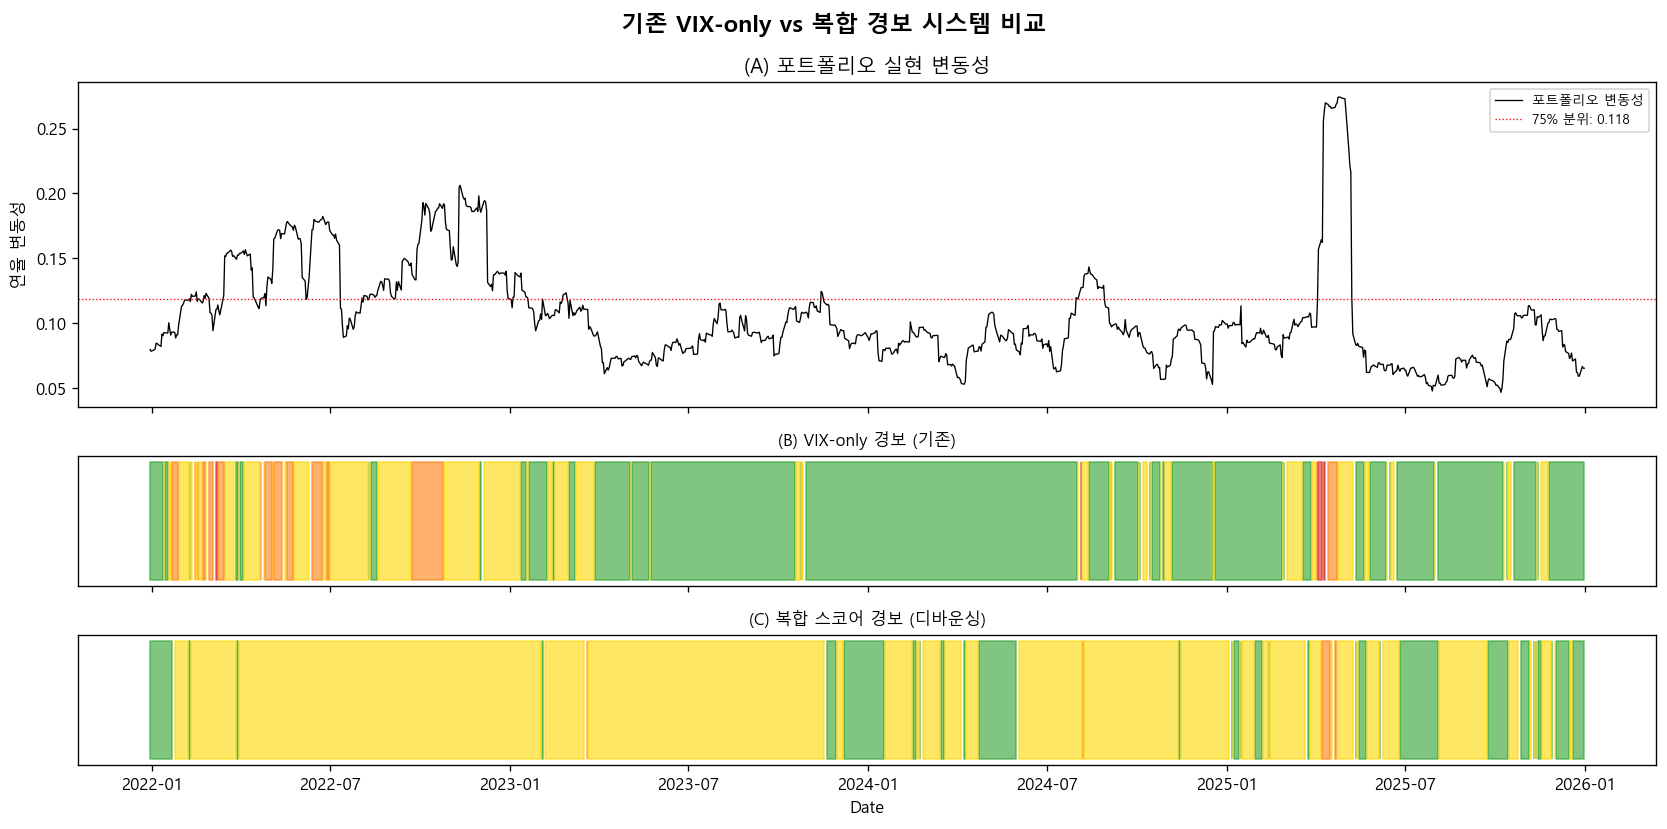

저장: images/alert_02_comparison.png


In [6]:
# ============================================================
# (2) VIX-only vs 복합 경보 비교 타임라인
# ============================================================

fig, axes = plt.subplots(3, 1, figsize=(14, 7), sharex=True,
                         gridspec_kw={'height_ratios': [2, 0.8, 0.8]})
fig.suptitle('기존 VIX-only vs 복합 경보 시스템 비교', fontsize=14, fontweight='bold')

# (A) 포트폴리오 변동성
ax = axes[0]
ax.plot(df_reg.index, df_reg['rv_neutral'], color='black', linewidth=0.8, label='포트폴리오 변동성')
ax.axhline(rv_75pct, color='red', linestyle=':', linewidth=0.8, label=f'75% 분위: {rv_75pct:.3f}')
ax.set_ylabel('연율 변동성')
ax.set_title('(A) 포트폴리오 실현 변동성')
ax.legend(fontsize=8)

# (B) VIX-only 경보
ax = axes[1]
for level in [0, 1, 2, 3]:
    mask = vix_alert == level
    ax.fill_between(df_reg.index, 0, 1, where=mask,
                    color=alert_colors[level], alpha=0.6)
ax.set_yticks([])
ax.set_title('(B) VIX-only 경보 (기존)', fontsize=10)

# (C) 복합 경보
ax = axes[2]
for level in [0, 1, 2, 3]:
    mask = df_reg['alert_debounced'] == level
    ax.fill_between(df_reg.index, 0, 1, where=mask,
                    color=alert_colors[level], alpha=0.6)
ax.set_yticks([])
ax.set_title('(C) 복합 스코어 경보 (디바운싱)', fontsize=10)
ax.set_xlabel('Date')

plt.tight_layout()
fig.savefig(os.path.join(IMG_DIR, 'alert_02_comparison.png'), bbox_inches='tight')
plt.show()
print('저장: images/alert_02_comparison.png')

In [7]:
# ============================================================
# 경보 시그널 CSV 저장
# ============================================================

alert_save = df_reg[['stress_score', 'alert_raw', 'alert_debounced', 'alert_name']].copy()
save_path = os.path.join(DATA_DIR, 'alert_signals.csv')
alert_save.to_csv(save_path)

print(f'저장: {save_path}')
print(f'Shape: {alert_save.shape}')

저장: C:\Users\gorhk\DA_Portfolio\01_Daily_Project\PJ12_Asset_Simulater\PJ12_v2_AltData\data\alert_signals.csv
Shape: (1045, 4)
